# This Notebook shows the process of creating the final Random Forest Model
### Business Impact and Model Interpretations are included as well

In [1]:
# Importing libraries
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.inspection import PartialDependenceDisplay
from sklearn.feature_selection import RFE
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

In [2]:
# Loading the 4 CSV files that contain the final data
df1 = pd.read_csv('Final_Run_First_Quarter_Clean.csv')
df2 = pd.read_csv('Final_Run_Second_Quarter_Clean.csv')
df3 = pd.read_csv('Final_Run_Third_Quarter_Clean.csv')
df4 = pd.read_csv('Final_Run_Fourth_Quarter_Clean.csv')

In [3]:
# Concatenate the dataframes to a single dataframe
final_data = pd.concat([df1, df2, df3, df4], axis=0, ignore_index=True)
len(final_data)

30596

In [6]:
# "job_completed" variable is the target variable
# False = Job Failure
# True = Job Completed
final_data['job_completed'].value_counts()

job_completed
False    15298
True     15298
Name: count, dtype: int64

In [7]:
final_data.head(2)

,id_job,id_array_job,id_array_task,id_user,kill_requid,nodes_alloc,nodelist,cpus_req,derived_ec,exit_code,gres_used,array_max_tasks,array_task_pending,constraints,flags,mem_req,partition,priority,state,timelimit,time_submit,time_eligible,time_start,time_end,time_suspended,track_steps,tres_alloc,tres_req,job_type,gpus_alloc,cpus_alloc,job_completed,duration_seconds,duration_hours,Job_Steps,Max_CPU_Util,Min_CPU_Util,Med_CPU_Util,IQR_CPU_Util,Max_RSS,Min_RSS,Med_RSS,IQR_RSS,Max_VMSize,Min_VMSize,Med_VMSize,IQR_VMSize,Max_Pages,Min_Pages,Med_Pages,IQR_Pages,Max_ReadMB,Min_ReadMB,Med_ReadMB,IQR_ReadMB,Max_WriteMB,Min_WriteMB,Med_WriteMB,IQR_WriteMB,Max_RSS_Velocity,Min_RSS_Velocity,Med_RSS_Velocity,IQR_RSS_Velocity,RSS_Slope,RSS_Accel,VMSize_Slope,Max_VM_RSS_Gap,Min_VM_RSS_Gap,Med_VM_RSS_Gap,IQR_VM_RSS_Gap,VM_RSS_Gap_Slope,Max_GPU_Util,Min_GPU_Util,Med_GPU_Util,IQR_GPU_Util,Max_Mem_Util,Min_Mem_Util,Med_Mem_Util,IQR_Mem_Util,Max_Temp_GPU,Min_Temp_GPU,Med_Temp_GPU,IQR_Temp_GPU,Max_Temp_Mem,Min_Temp_Mem,Med_Temp_Mem,IQR_Temp_Mem,Max_Power_Draw,Min_Power_Draw,Med_Power_Draw,IQR_Power_Draw,Power_Util_Ratio
0,44577838772074,12603536456035,107,36880203429568,61026541062099,1,['r9040233-n386398'],1,0,253,NaN,0,0,xeon-g6,8,9223372036854784308,normal,10014,11,525600,1612391473,1612391474,1612398284,1612423969,0,0,"1=1,2=8500,4=1,5=1","1=1,2=8500,4=1,5=1",LLSUB:BATCH,0,1,False,25685,7.134722,2,390.0,1.1,100.0,0.100,86890452.0,226204.0,343932.0,34844.0,154591168.0,283556.0,464412.0,35612.0,12.0,4.0,4.0,0.00,65.197869,0.000000,0.000000,0.000000,6.346914,0.000000,0.00000,0.00000,23642120.0,-86604148.0,0.0,0.0,-1744.291804,-0.224630,-2020.403806,84832344.0,44224.0,121468.0,2204.0,-276.112002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,38371777066344,105186008840,102,30273376745109,61026541062099,1,['r8607415-n976057'],1,0,0,NaN,0,0,xeon-g6,4,15360,normal,10365,6,240,1612459422,1612459428,1612459432,1612473846,0,0,"1=1,2=15360,3=18446744073709551614,4=1,5=1","1=1,2=15360,4=1,5=1",OTHER,0,1,False,14414,4.003889,2,1934.9,987.4,1547.0,89.025,11412224.0,735440.0,1254032.0,158138.0,186215632.0,19851532.0,29530300.0,165760.0,1432.0,116.0,773.5,601.75,9.072832,1.371466,6.053281,0.200696,15.274106,0.045257,0.08653,0.01434,10077004.0,-10218668.0,480.0,182112.0,27.861931,0.004728,818.566072,175289704.0,19086932.0,28287400.0,33625.0,790.704141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# I chose to not standardize feature values b/c Random Forest doesn't use distance metrics to find weights
# Standardizing would also make interpretability more difficult

In [8]:
# Train-Validate-Test Split

# Step 1: Split off the Test set (5% of the total data)
df_temp, df_test = train_test_split(
    final_data, 
    test_size=0.05, 
    random_state=30, 
    shuffle=True
)
# Step 2: Split the remaining 95% into Train (80%) and Validation (15%)
df_train, df_val = train_test_split(
    df_temp, 
    test_size=(15 / 95), 
    random_state=30, 
    shuffle=True
)
print(f"Total rows in original dataset: {len(final_data)}")
print(f"Train set (80%):       {len(df_train)} rows")
print(f"Validation set (15%):  {len(df_val)} rows")
print(f"Test set (5%):         {len(df_test)} rows")

Total rows in original dataset: 30596
Train set (80%):       24476 rows
Validation set (15%):  4590 rows
Test set (5%):         1530 rows


#
# Training Initial Random Forest Model

In [8]:
predictors = ['cpus_alloc', 'gpus_alloc', 'Max_CPU_Util', 'Min_CPU_Util', 'Med_CPU_Util', 'IQR_CPU_Util', 
              'RSS_Slope', 'Job_Steps', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'IQR_RSS', 'Max_VMSize', 'Min_VMSize',
              'Med_VMSize', 'IQR_VMSize', 'Max_Pages', 'Min_Pages', 'Med_Pages', 'IQR_Pages', 'Max_ReadMB', 
              'Min_ReadMB', 'Med_ReadMB', 'IQR_ReadMB', 'Max_WriteMB', 'Min_WriteMB', 'Med_WriteMB', 'IQR_WriteMB',
              'Max_RSS_Velocity', 'Min_RSS_Velocity', 'Med_RSS_Velocity', 'IQR_RSS_Velocity', 'RSS_Accel', 
              'VMSize_Slope', 'Max_VM_RSS_Gap', 'Min_VM_RSS_Gap', 'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap',
              'VM_RSS_Gap_Slope', 'Max_GPU_Util', 'Min_GPU_Util', 'Med_GPU_Util', 'IQR_GPU_Util',
              'Max_Mem_Util', 'Min_Mem_Util', 'Med_Mem_Util', 'IQR_Mem_Util',
              'Max_Temp_GPU', 'Min_Temp_GPU', 'Med_Temp_GPU', 'IQR_Temp_GPU',
              'Max_Temp_Mem', 'Min_Temp_Mem', 'Med_Temp_Mem', 'IQR_Temp_Mem',
              'Max_Power_Draw', 'Min_Power_Draw', 'Med_Power_Draw', 'IQR_Power_Draw', 'Power_Util_Ratio']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

# Using model to make predictions on the validation subset
val_predictions = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.9366013071895425

Validation Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.94      0.94      2292
        True       0.94      0.93      0.94      2298

    accuracy                           0.94      4590
   macro avg       0.94      0.94      0.94      4590
weighted avg       0.94      0.94      0.94      4590



In [9]:
# Listing the Most Important Predictors
importances = pd.Series(model.feature_importances_, index=predictors)
print("Top 10 Most Important Predictors:")
print(importances.sort_values(ascending=False).head(10))

Top 10 Most Important Predictors:
Med_CPU_Util        0.071709
Min_VMSize          0.049827
Min_RSS             0.041492
Med_RSS             0.038682
IQR_RSS_Velocity    0.036061
IQR_VM_RSS_Gap      0.034499
Med_VM_RSS_Gap      0.033150
Med_VMSize          0.033115
Max_VM_RSS_Gap      0.032150
Min_VM_RSS_Gap      0.031247
dtype: float64


In [10]:
# Listing the Least Important Predictors
print("Top 10 Least Important Predictors:")
print(importances.sort_values(ascending=True).head(10))

Top 10 Least Important Predictors:
Min_Mem_Util    0.000540
Min_GPU_Util    0.000544
gpus_alloc      0.001763
IQR_Temp_GPU    0.002651
IQR_Temp_Mem    0.002927
Min_Temp_Mem    0.003706
Med_Temp_GPU    0.003748
Med_Temp_Mem    0.003979
Min_Temp_GPU    0.003983
Max_Temp_Mem    0.004037
dtype: float64


In [11]:
# Checking Correlated Variable Pairs
corr_matrix = X_train.corr()
unstacked_corr = corr_matrix.unstack()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Filter out "self-correlations" (where correlation is 1.0)
top_10_pairs = sorted_corr[len(X_train.columns):].head(20)
unique_top_10 = top_10_pairs.iloc[::2]

print("Top 10 Most Correlated Variable Pairs:")
print(unique_top_10)

Top 10 Most Correlated Variable Pairs:
Min_VM_RSS_Gap    Min_VMSize          0.999785
Med_VMSize        Med_VM_RSS_Gap      0.998583
VM_RSS_Gap_Slope  VMSize_Slope        0.997206
IQR_VM_RSS_Gap    IQR_VMSize          0.996776
Max_VM_RSS_Gap    Max_VMSize          0.993600
Med_Temp_GPU      Med_Temp_Mem        0.984985
Max_Temp_Mem      Max_Temp_GPU        0.981769
Min_Temp_GPU      Min_Temp_Mem        0.977915
IQR_Temp_GPU      IQR_Temp_Mem        0.965595
Max_RSS           Max_RSS_Velocity    0.958709
dtype: float64


In [12]:
# Checking accuracy differences for GPU jobs vs non-GPU jobs
gpu_mask = X_val['gpus_alloc'] >= 1
non_gpu_mask = X_val['gpus_alloc'] == 0

y_val_gpu = y_val[gpu_mask]
preds_gpu = val_predictions[gpu_mask]
y_val_nongpu = y_val[non_gpu_mask]
preds_nongpu = val_predictions[non_gpu_mask]

print("GPU JOBS")
print(f"Accuracy: {accuracy_score(y_val_gpu, preds_gpu):.4f}")
print(classification_report(y_val_gpu, preds_gpu))
print("NON-GPU JOBS")
print(f"Accuracy: {accuracy_score(y_val_nongpu, preds_nongpu):.4f}")
print(classification_report(y_val_nongpu, preds_nongpu))

GPU JOBS
Accuracy: 0.9301
              precision    recall  f1-score   support

       False       0.92      0.95      0.94      1124
        True       0.94      0.90      0.92       922

    accuracy                           0.93      2046
   macro avg       0.93      0.93      0.93      2046
weighted avg       0.93      0.93      0.93      2046

NON-GPU JOBS
Accuracy: 0.9418
              precision    recall  f1-score   support

       False       0.94      0.93      0.94      1168
        True       0.94      0.95      0.95      1376

    accuracy                           0.94      2544
   macro avg       0.94      0.94      0.94      2544
weighted avg       0.94      0.94      0.94      2544



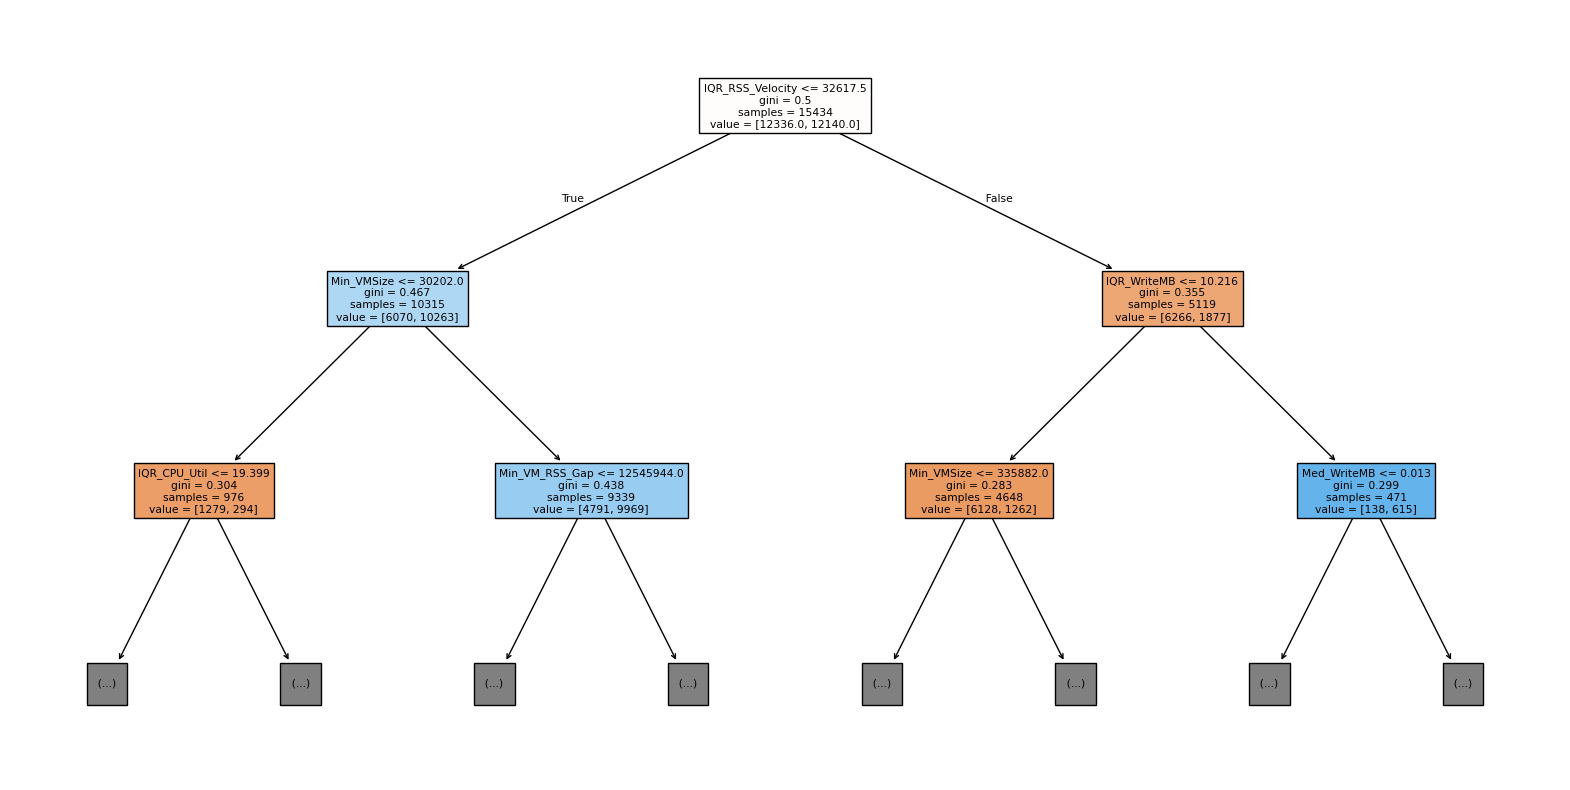

In [13]:
# Showing one of the decision trees as an example
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[1], 
          feature_names=predictors, 
          filled=True, 
          max_depth=2)  # Limiting depth so it's readable
plt.show()

#
# Making a completely new model for classifying the final job state, instead of Completed/Failed

In [14]:
# Testing a multiclass classifier model

predictors = ['cpus_alloc', 'gpus_alloc', 'Max_CPU_Util', 'Min_CPU_Util', 'Med_CPU_Util', 'IQR_CPU_Util', 
              'RSS_Slope', 'Job_Steps', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'IQR_RSS', 'Max_VMSize', 'Min_VMSize',
             'Med_VMSize', 'IQR_VMSize', 'Max_Pages', 'Min_Pages', 'Med_Pages', 'IQR_Pages',
             'Max_ReadMB', 'Min_ReadMB', 'Med_ReadMB', 'IQR_ReadMB', 'Max_WriteMB', 'Min_WriteMB', 'Med_WriteMB', 'IQR_WriteMB',
             'Max_RSS_Velocity', 'Min_RSS_Velocity', 'Med_RSS_Velocity', 'IQR_RSS_Velocity', 'RSS_Accel', 
             'VMSize_Slope', 'Max_VM_RSS_Gap', 'Min_VM_RSS_Gap', 'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap',
             'VM_RSS_Gap_Slope', 'Max_GPU_Util', 'Min_GPU_Util', 'Med_GPU_Util', 'IQR_GPU_Util',
             'Max_Mem_Util', 'Min_Mem_Util', 'Med_Mem_Util', 'IQR_Mem_Util',
             'Max_Temp_GPU', 'Min_Temp_GPU', 'Med_Temp_GPU', 'IQR_Temp_GPU',
             'Max_Temp_Mem', 'Min_Temp_Mem', 'Med_Temp_Mem', 'IQR_Temp_Mem',
             'Max_Power_Draw', 'Min_Power_Draw', 'Med_Power_Draw', 'IQR_Power_Draw', 'Power_Util_Ratio']
target = 'state'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

# Using model to make predictions on the validation subset
val_predictions = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.9115468409586057

Validation Classification Report:
              precision    recall  f1-score   support

           3       0.92      0.95      0.93      2298
           5       0.83      0.82      0.82       952
           6       0.97      0.92      0.94      1011
          11       0.91      0.91      0.91       329

    accuracy                           0.91      4590
   macro avg       0.91      0.90      0.90      4590
weighted avg       0.91      0.91      0.91      4590



In [ ]:
# Overall Model accuracy is lower than the binary classification model
# Easier to predict Timeout(state 6) and Out of Memory(state 11) failures
# Harder to predict General Crash (state 5) failures

In [15]:
# Listing the Most Important Predictors
importances = pd.Series(model.feature_importances_, index=predictors)
print("Top 10 Most Important Predictors:")
print(importances.sort_values(ascending=False).head(10))

Top 10 Most Important Predictors:
Med_CPU_Util        0.066312
Min_VMSize          0.052772
IQR_RSS_Velocity    0.046323
Job_Steps           0.045593
Min_RSS             0.042876
Med_RSS             0.039966
Min_VM_RSS_Gap      0.039820
Med_VM_RSS_Gap      0.032740
Med_VMSize          0.031329
IQR_VM_RSS_Gap      0.031275
dtype: float64


#
# Making a third model just for the GPU jobs to see if the GPU features are important to them

In [16]:
# Create new subset
gpu_jobs_df = final_data[final_data['gpus_alloc'] > 0]
print(len(gpu_jobs_df))

13856


In [17]:
predictors = ['cpus_alloc', 'gpus_alloc', 'Max_CPU_Util', 'Min_CPU_Util', 'Med_CPU_Util', 'IQR_CPU_Util', 
              'RSS_Slope', 'Job_Steps', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'IQR_RSS', 'Max_VMSize', 'Min_VMSize',
             'Med_VMSize', 'IQR_VMSize', 'Max_Pages', 'Min_Pages', 'Med_Pages', 'IQR_Pages',
             'Max_ReadMB', 'Min_ReadMB', 'Med_ReadMB', 'IQR_ReadMB', 'Max_WriteMB', 'Min_WriteMB', 'Med_WriteMB', 'IQR_WriteMB',
             'Max_RSS_Velocity', 'Min_RSS_Velocity', 'Med_RSS_Velocity', 'IQR_RSS_Velocity', 'RSS_Accel', 
             'VMSize_Slope', 'Max_VM_RSS_Gap', 'Min_VM_RSS_Gap', 'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap',
             'VM_RSS_Gap_Slope', 'Max_GPU_Util', 'Min_GPU_Util', 'Med_GPU_Util', 'IQR_GPU_Util',
             'Max_Mem_Util', 'Min_Mem_Util', 'Med_Mem_Util', 'IQR_Mem_Util',
             'Max_Temp_GPU', 'Min_Temp_GPU', 'Med_Temp_GPU', 'IQR_Temp_GPU',
             'Max_Temp_Mem', 'Min_Temp_Mem', 'Med_Temp_Mem', 'IQR_Temp_Mem',
             'Max_Power_Draw', 'Min_Power_Draw', 'Med_Power_Draw', 'IQR_Power_Draw', 'Power_Util_Ratio']
target = 'job_completed'

X = gpu_jobs_df[predictors]
y = gpu_jobs_df[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.05, random_state=30, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1579, random_state=30, stratify=y_temp)

print(f"Training set:   {X_train.shape[0]} rows (≈80%)")
print(f"Validation set: {X_val.shape[0]} rows (≈15%)")
print(f"Testing set:    {X_test.shape[0]} rows (≈5%)")

Training set:   11084 rows (≈80%)
Validation set: 2079 rows (≈15%)
Testing set:    693 rows (≈5%)


In [18]:
# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

# Using model to make predictions on the validation subset
val_predictions = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.935064935064935

Validation Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.96      0.94      1169
        True       0.94      0.91      0.92       910

    accuracy                           0.94      2079
   macro avg       0.94      0.93      0.93      2079
weighted avg       0.94      0.94      0.93      2079



In [19]:
# Listing the Most Important Predictors
importances = pd.Series(model.feature_importances_, index=predictors)
print("Top 10 Most Important Predictors:")
print(importances.sort_values(ascending=False).head(10))

Top 10 Most Important Predictors:
Med_WriteMB       0.061411
Med_CPU_Util      0.050334
Min_RSS           0.047589
Min_VMSize        0.045902
Min_VM_RSS_Gap    0.038569
Med_VMSize        0.037104
Med_RSS           0.032736
Med_VM_RSS_Gap    0.028921
Max_Mem_Util      0.023210
Min_CPU_Util      0.022814
dtype: float64


In [20]:
# Listing the Least Important Predictors
print("Top 10 Least Important Predictors:")
print(importances.sort_values(ascending=True).head(10))

Top 10 Least Important Predictors:
Min_Mem_Util    0.000720
Min_GPU_Util    0.000725
gpus_alloc      0.002640
IQR_Temp_GPU    0.004079
Min_Pages       0.004219
IQR_Temp_Mem    0.004333
IQR_Pages       0.005422
Min_Temp_GPU    0.005838
Med_Pages       0.006003
Min_Temp_Mem    0.006238
dtype: float64


In [ ]:
# This GPU-job-only model had roughly the same accuracy as the first general binary model I trained, and the GPU features are unimportant
# This being the case, I will stick with Plan A and train a general binary classification model

# 
# Tuning the first/general model, since it's the one I want to go with

In [21]:
# Generate a completely random continuous variable for feature importance comparisons
np.random.seed(30)
df_train['RANDOM_VARIABLE'] = np.random.uniform(0, 100, size=len(df_train))
df_val['RANDOM_VARIABLE'] = np.random.uniform(0, 100, size=len(df_val))
df_test['RANDOM_VARIABLE'] = np.random.uniform(0, 100, size=len(df_test))

In [22]:
df_train[['id_job', 'RANDOM_VARIABLE']].head(2)

,id_job,RANDOM_VARIABLE
8671,12003149199450,64.414354
784,80168996440804,38.074849


In [23]:
predictors = ['RANDOM_VARIABLE', 'cpus_alloc', 'gpus_alloc', 'Max_CPU_Util', 'Min_CPU_Util', 'Med_CPU_Util', 'IQR_CPU_Util', 
              'RSS_Slope', 'Job_Steps', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'IQR_RSS', 'Max_VMSize', 'Min_VMSize',
             'Med_VMSize', 'IQR_VMSize', 'Max_Pages', 'Min_Pages', 'Med_Pages', 'IQR_Pages',
             'Max_ReadMB', 'Min_ReadMB', 'Med_ReadMB', 'IQR_ReadMB', 'Max_WriteMB', 'Min_WriteMB', 'Med_WriteMB', 'IQR_WriteMB',
             'Max_RSS_Velocity', 'Min_RSS_Velocity', 'Med_RSS_Velocity', 'IQR_RSS_Velocity', 'RSS_Accel', 
             'VMSize_Slope', 'Max_VM_RSS_Gap', 'Min_VM_RSS_Gap', 'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap',
             'VM_RSS_Gap_Slope', 'Max_GPU_Util', 'Min_GPU_Util', 'Med_GPU_Util', 'IQR_GPU_Util',
             'Max_Mem_Util', 'Min_Mem_Util', 'Med_Mem_Util', 'IQR_Mem_Util',
             'Max_Temp_GPU', 'Min_Temp_GPU', 'Med_Temp_GPU', 'IQR_Temp_GPU',
             'Max_Temp_Mem', 'Min_Temp_Mem', 'Med_Temp_Mem', 'IQR_Temp_Mem',
             'Max_Power_Draw', 'Min_Power_Draw', 'Med_Power_Draw', 'IQR_Power_Draw', 'Power_Util_Ratio']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Listing the Predictors by Importance with Random Variable for comparison
importances = pd.Series(model.feature_importances_, index=predictors)
with pd.option_context("display.max_rows", 100):
    print(importances.sort_values(ascending=False))

Med_CPU_Util        0.070938
Min_RSS             0.046564
Min_VMSize          0.042471
IQR_RSS_Velocity    0.039500
Min_VM_RSS_Gap      0.035437
Med_VMSize          0.035406
Med_RSS             0.034379
Med_VM_RSS_Gap      0.032978
IQR_VMSize          0.030145
IQR_VM_RSS_Gap      0.029316
Max_VM_RSS_Gap      0.028948
Max_VMSize          0.028680
Max_CPU_Util        0.028350
Max_RSS             0.026726
Min_CPU_Util        0.025582
Max_ReadMB          0.024510
Max_WriteMB         0.023235
Min_RSS_Velocity    0.022505
Med_WriteMB         0.022154
Job_Steps           0.021639
Max_RSS_Velocity    0.020321
cpus_alloc          0.020132
IQR_CPU_Util        0.018826
VMSize_Slope        0.017870
IQR_WriteMB         0.016873
VM_RSS_Gap_Slope    0.016071
RSS_Slope           0.014396
IQR_RSS             0.013836
RSS_Accel           0.013556
Max_Mem_Util        0.012848
Med_RSS_Velocity    0.012237
Med_ReadMB          0.011187
IQR_ReadMB          0.010626
Med_Mem_Util        0.010441
Max_Power_Draw

In [ ]:
# I will remove variables that are less important than a random variable
# I will also remove variables with over 90% correlation (keeping the more important of the two)
# Random Forest models are robust in the face of multicollinearity, but over 90% correlation are virtual copies

In [26]:
# Checking Correlated Variable Pairs
corr_matrix = X_train.corr()
unstacked_corr = corr_matrix.unstack()
sorted_corr = unstacked_corr.sort_values(ascending=False)

# Filter out "self-correlations" (where correlation is 1.0)
top_12_pairs = sorted_corr[len(X_train.columns):].head(24)
unique_top_12 = top_12_pairs.iloc[::2]

print("Top 12 Most Correlated Variable Pairs:")
print(unique_top_12)

Top 12 Most Correlated Variable Pairs:
Min_VM_RSS_Gap    Min_VMSize        0.999785
Med_VMSize        Med_VM_RSS_Gap    0.998583
VM_RSS_Gap_Slope  VMSize_Slope      0.997206
IQR_VMSize        IQR_VM_RSS_Gap    0.996776
Max_VMSize        Max_VM_RSS_Gap    0.993600
Med_Temp_GPU      Med_Temp_Mem      0.984985
Max_Temp_Mem      Max_Temp_GPU      0.981769
Min_Temp_Mem      Min_Temp_GPU      0.977915
IQR_Temp_Mem      IQR_Temp_GPU      0.965595
Max_RSS_Velocity  Max_RSS           0.958709
Med_Temp_Mem      Med_Power_Draw    0.901684
Med_Pages         IQR_Pages         0.897402
dtype: float64


In [47]:
# Variables to Remove:

# Min_WriteMB, IQR_Pages, Min_ReadMB, Min_Power_Draw, IQR_Mem_Util, 
# Min_Pages, IQR_GPU_Util, Med_Temp_GPU, Max_Temp_Mem, Min_Temp_GPU
# Max_Temp_GPU, Med_Temp_Mem, Min_Temp_Mem, IQR_Temp_Mem, IQR_Temp_GPU
# gpus_alloc, Min_GPU_Util, Min_Mem_Util, Min_VM_RSS_Gap, Med_VMSize,
# VMSize_Slope, IQR_VMSize, Max_VMSize, Max_RSS_Velocity

#
# Training Updated Model with unimportant and/or highly correlated variables removed

In [27]:
# Reduced Random Forest Model

predictors = ['RANDOM_VARIABLE', 'cpus_alloc', 'Max_CPU_Util', 'Min_CPU_Util', 'Med_CPU_Util', 'IQR_CPU_Util', 
              'RSS_Slope', 'Job_Steps', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'IQR_RSS', 'Min_VMSize', 'Max_Pages', 
              'Med_Pages', 'Max_ReadMB', 'Med_ReadMB', 'IQR_ReadMB', 'Max_WriteMB', 'Med_WriteMB', 'IQR_WriteMB',
              'Min_RSS_Velocity', 'Med_RSS_Velocity', 'IQR_RSS_Velocity', 'RSS_Accel', 'Max_VM_RSS_Gap', 
              'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap', 'VM_RSS_Gap_Slope', 'Max_GPU_Util', 'Med_GPU_Util', 
              'Max_Mem_Util', 'Med_Mem_Util', 'Max_Power_Draw', 'Med_Power_Draw', 'IQR_Power_Draw', 'Power_Util_Ratio']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

# Using model to make predictions on the validation subset
val_predictions = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.937037037037037

Validation Classification Report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2292
        True       0.94      0.94      0.94      2298

    accuracy                           0.94      4590
   macro avg       0.94      0.94      0.94      4590
weighted avg       0.94      0.94      0.94      4590



Text(0.5, 1.0, 'Which columns predicted the target best?')

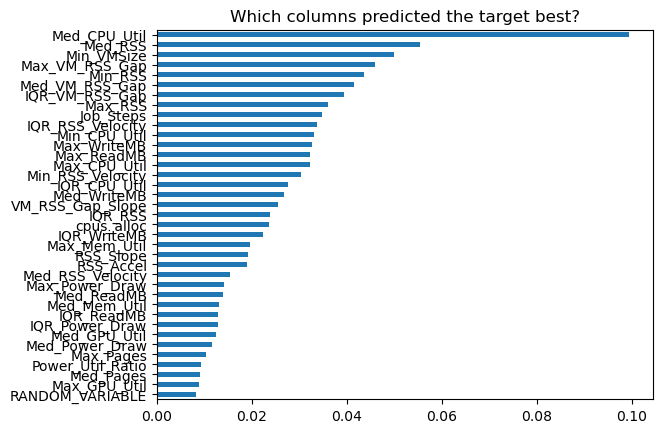

In [28]:
# Showing Feature Importance (Keeping Random Variable just to show that we removed the right predictors
importances = pd.Series(model.feature_importances_, index=predictors)
importances.sort_values().plot(kind='barh')
plt.title("Which columns predicted the target best?")

In [29]:
# Showing that no more variables are over 90% correllated
corr_matrix = X_train.corr()
unstacked_corr = corr_matrix.unstack()
sorted_corr = unstacked_corr.sort_values(ascending=False)

top_10_pairs = sorted_corr[len(X_train.columns):].head(20)
unique_top_10 = top_10_pairs.iloc[::2]

print("Top 10 Most Correlated Variable Pairs:")
print(unique_top_10)

Top 10 Most Correlated Variable Pairs:
Med_GPU_Util    Med_Power_Draw    0.896027
Max_GPU_Util    Max_Power_Draw    0.870309
Max_VM_RSS_Gap  Med_VM_RSS_Gap    0.826806
Max_Power_Draw  Max_Mem_Util      0.825547
Max_Pages       Med_Pages         0.823664
Med_Power_Draw  Med_Mem_Util      0.815358
Med_Mem_Util    Med_GPU_Util      0.813188
Max_GPU_Util    Max_Mem_Util      0.810896
Med_ReadMB      IQR_ReadMB        0.750442
RSS_Accel       RSS_Slope         0.731414
dtype: float64


#
# Attempting to lower the feature count to see if we can cut out more complexity without sacrificing accuracy:
### Created a loop to make 1 entire model for each number of features from 1 to 35.
### This should indicate where the point of dimishing accuracy returns is.

In [30]:
feature_list = ['Med_CPU_Util', 'Med_RSS', 'Min_VMSize', 'Max_VM_RSS_Gap', 'Min_RSS', 'Med_VM_RSS_Gap',
                'IQR_VM_RSS_Gap', 'Max_RSS', 'Job_Steps', 'IQR_RSS_Velocity', 'Min_CPU_Util',
                'Max_WriteMB', 'Max_ReadMB', 'Max_CPU_Util', 'Min_RSS_Velocity', 'IQR_CPU_Util',
                'Med_WriteMB', 'VM_RSS_Gap_Slope', 'IQR_RSS', 'cpus_alloc', 'IQR_WriteMB', 'Max_Mem_Util',
                'RSS_Slope', 'RSS_Accel', 'Med_RSS_Velocity', 'Max_Power_Draw', 'Med_ReadMB', 
                'Med_Mem_Util', 'IQR_ReadMB', 'IQR_Power_Draw', 'Med_GPU_Util', 'Med_Power_Draw',
                'Max_Pages', 'Power_Util_Ratio', 'Med_Pages', 'Max_GPU_Util']

target = 'job_completed'
y_train = df_train[target]
y_val = df_val[target]

# Create an empty list to store results
performance_results = []

# Loop from 1 to the total number of features (35)
for i in range(1, len(feature_list)):
    # Slice the list to get the first 'i' features
    current_predictors = feature_list[:i]
    # Subset the training and validation data
    X_train = df_train[current_predictors]
    X_val = df_val[current_predictors]
    # Initialize a fresh model
    model = RandomForestClassifier(random_state=30, n_jobs=-1)
    # Fit the model and make predictions
    model.fit(X_train, y_train)
    val_predictions = model.predict(X_val)
    # Calculate accuracy
    accuracy = accuracy_score(y_val, val_predictions)
    # Append the results as a dictionary
    performance_results.append({
        'Number of Predictors': i,
        'Model Accuracy': accuracy
    })
    
results_df = pd.DataFrame(performance_results)
print("\n--- Final Results ---")
print(results_df)


--- Final Results ---
    Number of Predictors  Model Accuracy
0                      1        0.734423
1                      2        0.856863
2                      3        0.908061
3                      4        0.920915
4                      5        0.923094
5                      6        0.926797
6                      7        0.925708
7                      8        0.926797
8                      9        0.927015
9                     10        0.929194
10                    11        0.927887
11                    12        0.933987
12                    13        0.935512
13                    14        0.936383
14                    15        0.933551
15                    16        0.935294
16                    17        0.936383
17                    18        0.936819
18                    19        0.934423
19                    20        0.935512
20                    21        0.935076
21                    22        0.936601
22                    23        0.

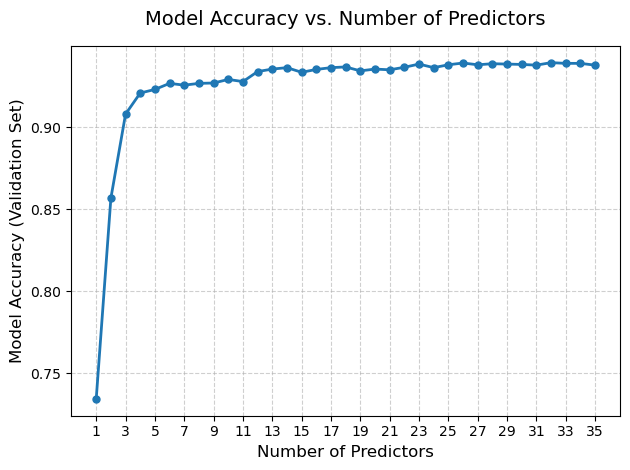

In [31]:
# Plotting the change in accuracy with the increased number of features
plt.plot(
    results_df["Number of Predictors"],
    results_df["Model Accuracy"],
    marker="o",
    linestyle="-",
    color="#1f77b4",
    linewidth=2,
    markersize=5,
)

plt.title("Model Accuracy vs. Number of Predictors", fontsize=14, pad=15)
plt.xlabel("Number of Predictors", fontsize=12)
plt.ylabel("Model Accuracy (Validation Set)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, 37, 2))
plt.tight_layout()

In [ ]:
# Note: 4 predictor variables (features) provides simplicity at the cost of just ~1% accuracy
# This seems like an ideal number of features for the final model

#
# Training model with top 10 features to get updated order of feature importance

In [32]:
predictors = ['Max_CPU_Util', 'Med_CPU_Util', 'Max_RSS', 'Min_RSS', 'Med_RSS', 'Min_VMSize', 
              'Max_WriteMB', 'Max_VM_RSS_Gap', 'Med_VM_RSS_Gap', 'IQR_VM_RSS_Gap']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

# Fitting the model
model = RandomForestClassifier(random_state=30)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Text(0.5, 1.0, 'Which columns predicted the target best?')

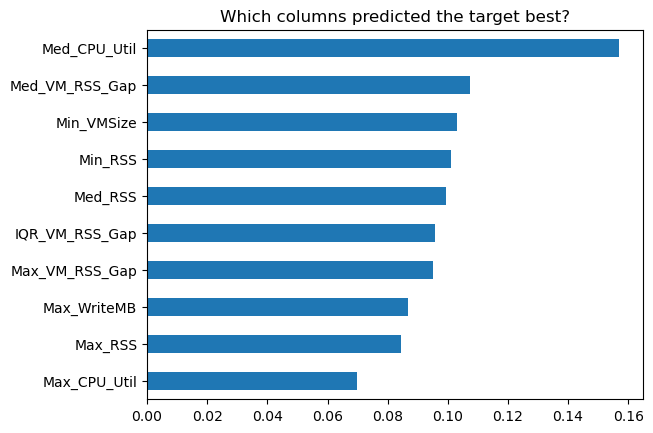

In [33]:
importances = pd.Series(model.feature_importances_, index=predictors)
importances.sort_values().plot(kind='barh')
plt.title("Which columns predicted the target best?")

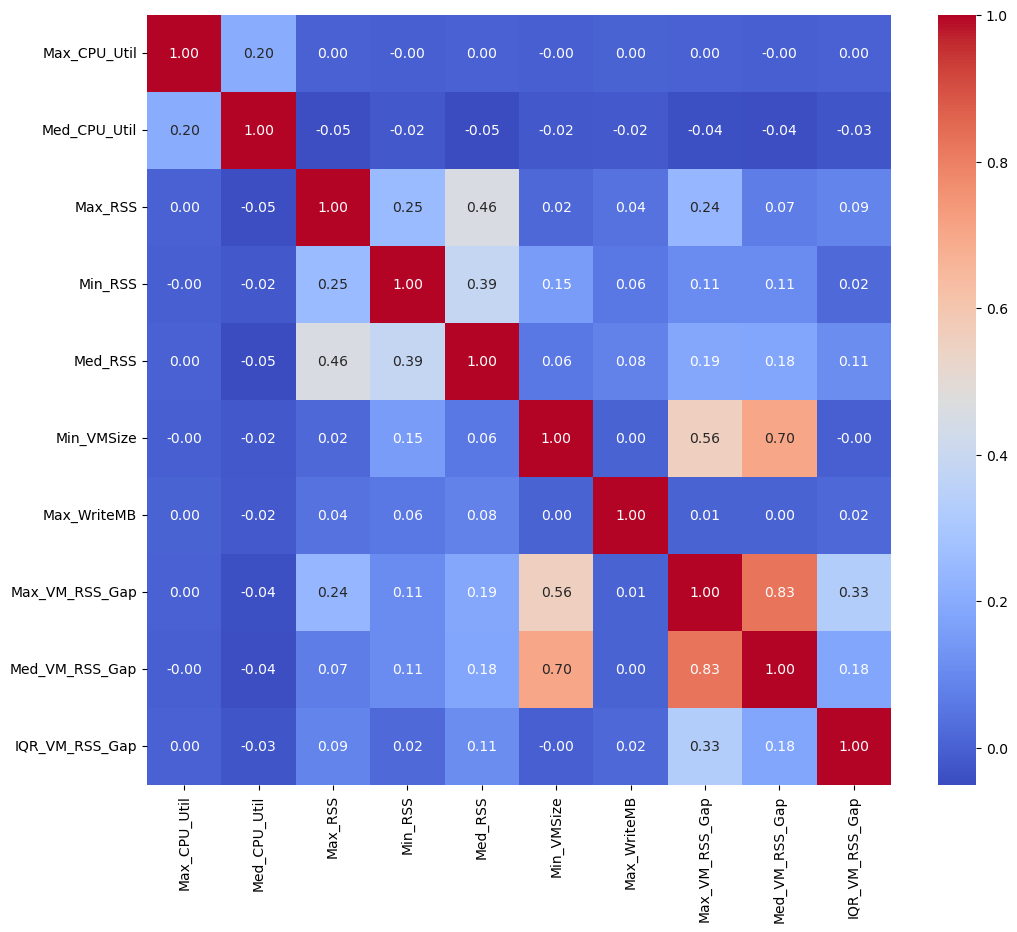

In [34]:
# Correlation matrix
corr_matrix = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [35]:
# Recursive Feature Elimination to find the final four features:
model = RandomForestClassifier(random_state=30)

selector = RFE(estimator=model, n_features_to_select=4, step=1)
selector.fit(X_train, y_train)

optimized_features = X_train.columns[selector.support_]
print("The mathematically optimal 4 features are:")
print(optimized_features)

The mathematically optimal 4 features are:
Index(['Med_CPU_Util', 'Min_RSS', 'Med_RSS', 'Med_VM_RSS_Gap'], dtype='object')


#
# Final Random Forest Model

In [9]:
predictors = ['Med_CPU_Util', 'Min_RSS', 'Med_RSS', 'Med_VM_RSS_Gap']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]
X_test = df_test[predictors]
y_test = df_test[target]

# Fitting the model
model_2 = RandomForestClassifier(random_state=30)
model_2.fit(X_train, y_train)

# Getting accuracy score before tuning hyperparameters for baseline:
val_predictions = model_2.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.920479302832244

Validation Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.92      0.92      2292
        True       0.92      0.92      0.92      2298

    accuracy                           0.92      4590
   macro avg       0.92      0.92      0.92      4590
weighted avg       0.92      0.92      0.92      4590



In [37]:
# Now to tune the model hyperparameters
# Utilizing Grid Search CV to find the optimized hyperparameters:

rf = RandomForestClassifier(random_state=30)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],      # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],      # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],        # Minimum samples required to be at a leaf node
    'max_features': ['sqrt', 'log2']      # Number of features to consider at every split
}

# Setup the GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    estimator = rf, 
    param_grid = param_grid, 
    cv = 5, 
    n_jobs = -1, 
    verbose = 2
)

# Fit the Grid Search to training data
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Output the best results
print("\n--- Grid Search Complete ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

--- Grid Search Complete ---
Best Hyperparameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.9149


In [10]:
# Train the Final model
Final_Model = RandomForestClassifier(max_depth=30, max_features='sqrt', min_samples_leaf=1, 
                                     min_samples_split=2, n_estimators=100, random_state=30)
Final_Model.fit(X_train, y_train)

# Make final predictions on the Validation subset
val_predictions = Final_Model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions)}")
print("\nValidation Classification Report:")
print(classification_report(y_val, val_predictions))

Validation Accuracy: 0.9206971677559913

Validation Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.92      0.92      2292
        True       0.92      0.92      0.92      2298

    accuracy                           0.92      4590
   macro avg       0.92      0.92      0.92      4590
weighted avg       0.92      0.92      0.92      4590



## Tuning of hyperparameters increased overall accuracy on validation set by a very small amount

In [11]:
# Make final predictions on the TEST set
final_predictions = Final_Model.predict(X_test)
print(f"Final Model Accuracy: {accuracy_score(y_test, final_predictions)}")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Model Accuracy: 0.9241830065359478

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.93      0.92       748
        True       0.93      0.92      0.93       782

    accuracy                           0.92      1530
   macro avg       0.92      0.92      0.92      1530
weighted avg       0.92      0.92      0.92      1530



## Final Random Forest Model overall accuracy of 92.4%
#### Note that this accuracy is based on a decision threshold value of 0.5, so a prediction confidence of 50% or higher determines if the model thinks the job failed (false) or succeeded (true) 

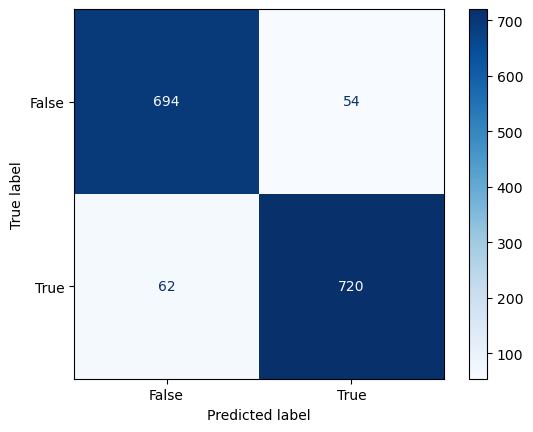

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Final_Model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Text(0.5, 1.0, 'Which columns predicted the target best?')

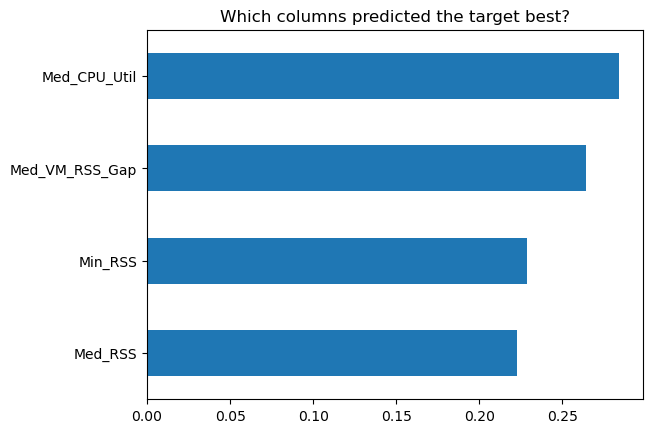

In [10]:
# Showing Feature Importance
final_importances = pd.Series(Final_Model.feature_importances_, index=predictors)
final_importances.sort_values().plot(kind='barh')
plt.title("Which columns predicted the target best?")

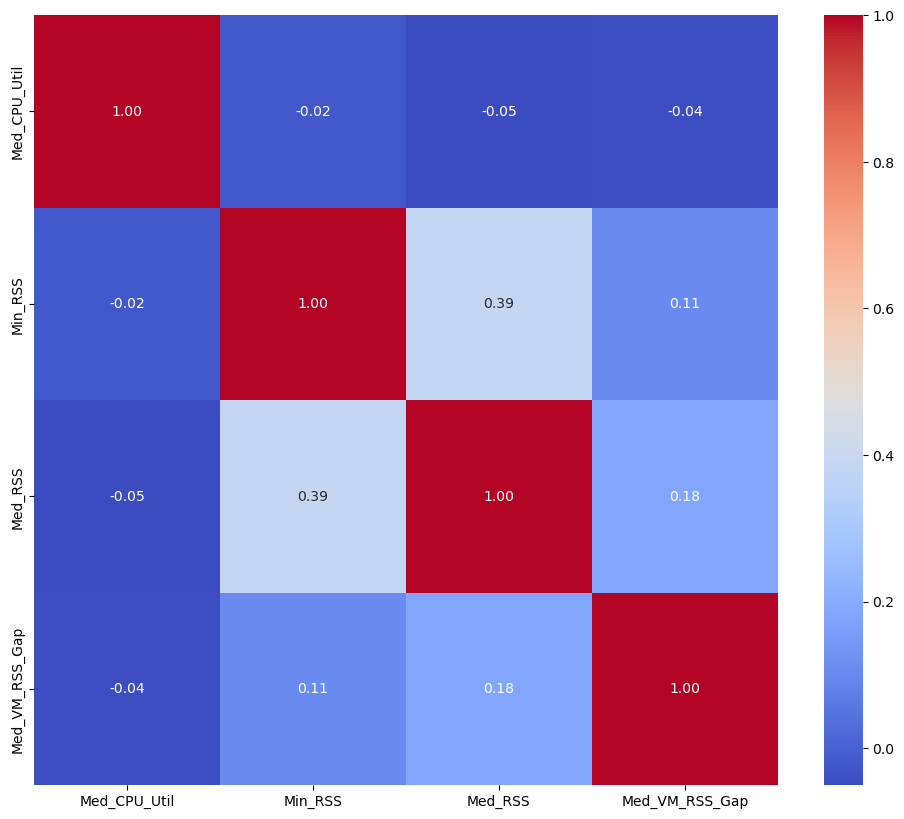

In [11]:
# Compute the correlation matrix
corr_matrix = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [12]:
# Exporting Final Model to be deployed to AWS
import joblib
joblib.dump(Final_Model, 'final_model.joblib')
print("🎉 Model successfully exported!")

🎉 Model successfully exported!


#
# Training XGBoost Model with same feature list 
### Just to see if it can do any better than the Random Forest Model

In [42]:
predictors = ['Med_CPU_Util', 'Min_RSS', 'Med_RSS', 'Med_VM_RSS_Gap']
target = 'job_completed'

X_train = df_train[predictors]
y_train = df_train[target]
X_val = df_val[predictors]
y_val = df_val[target]

model_xgb = XGBClassifier(
    n_estimators=100,       # Number of gradient boosted trees
    max_depth=30,            # Maximum depth of a tree (XGBoost default is 6)
    learning_rate=0.1,      # Step size shrinkage to prevent overfitting
    random_state=30,
    n_jobs=-1               
)

# Fit the model and make predictions
model_xgb.fit(X_train, y_train)
val_predictions = model_xgb.predict(X_val)
accuracy = accuracy_score(y_val, val_predictions)

print("\n--- Model Evaluation ---")
print(f"Validation Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, val_predictions))


--- Model Evaluation ---
Validation Accuracy: 0.9124

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.92      0.91      2292
        True       0.92      0.91      0.91      2298

    accuracy                           0.91      4590
   macro avg       0.91      0.91      0.91      4590
weighted avg       0.91      0.91      0.91      4590



In [ ]:
# XGBoost Performance inferior to Random Forest, so I will not change Final Model

#
# Creating Partial Dependence Plots to show interpretability
### The X-axis represents the range of values for the feature in question.
### The Y-axis represents the predicted probability of the target class (Job Failure)

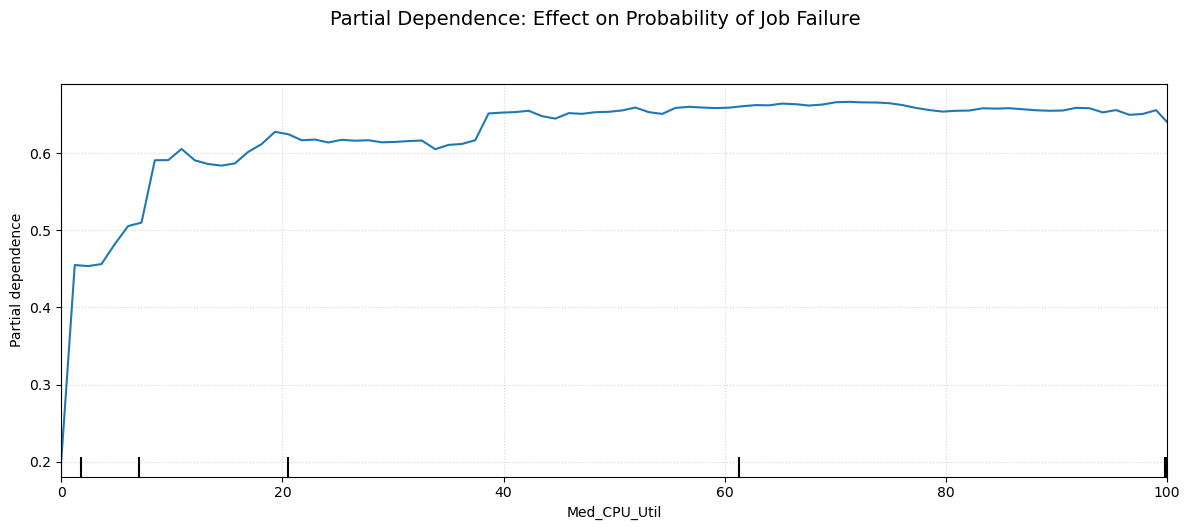

In [12]:
# Plot for Median CPU Utilization
features_to_plot = ['Med_CPU_Util']

# Take a representative sample of 1,000 rows to keep computation fast
X_sample = X_test.sample(n=min(1000, len(X_val)), random_state=30)

# Create the plot grid
fig, ax = plt.subplots(figsize=(12, 5))

# Generate the plots
display = PartialDependenceDisplay.from_estimator(
    estimator=Final_Model, 
    X=X_sample,
    features=features_to_plot,
    response_method='predict_proba', 
    ax=ax,
    grid_resolution=500 
)
plt.gca().set_xlim(0, 100)

# Customize the layout
plt.suptitle("Partial Dependence: Effect on Probability of Job Failure", y=1.05, fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

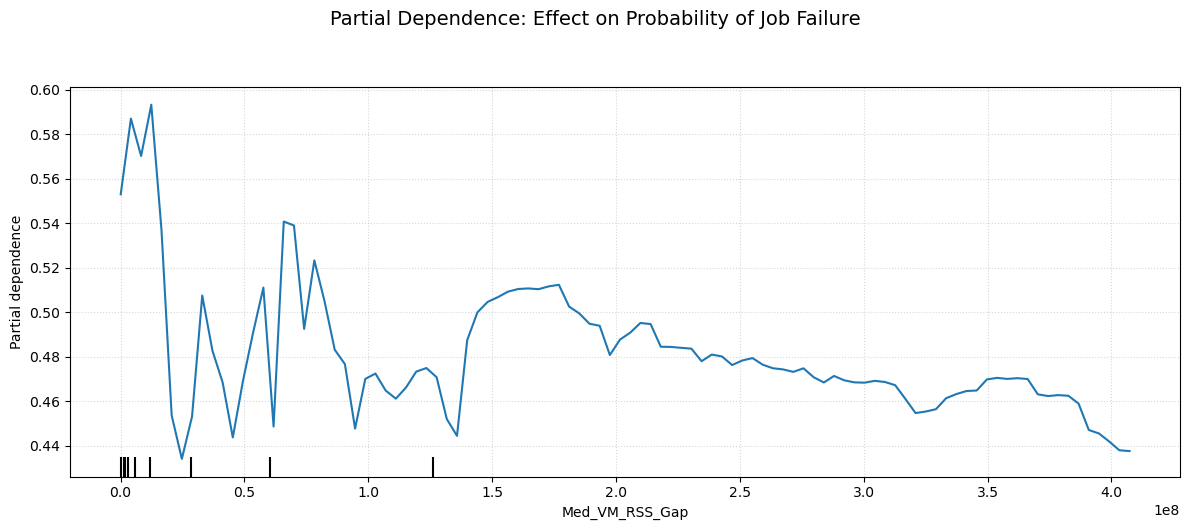

In [14]:
# Plot for Median VMSize - RSS Gap
# As a reminder, this gap is an engineered value for the simple difference between VM Size and RSS

features_to_plot = ['Med_VM_RSS_Gap']
X_sample = X_test.sample(n=min(1000, len(X_val)), random_state=30)
fig, ax = plt.subplots(figsize=(12, 5))

display = PartialDependenceDisplay.from_estimator(
    estimator=Final_Model, 
    X=X_sample,
    features=features_to_plot,
    response_method='predict_proba',
    ax=ax,
    grid_resolution=100 
)

plt.suptitle("Partial Dependence: Effect on Probability of Job Failure", y=1.05, fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

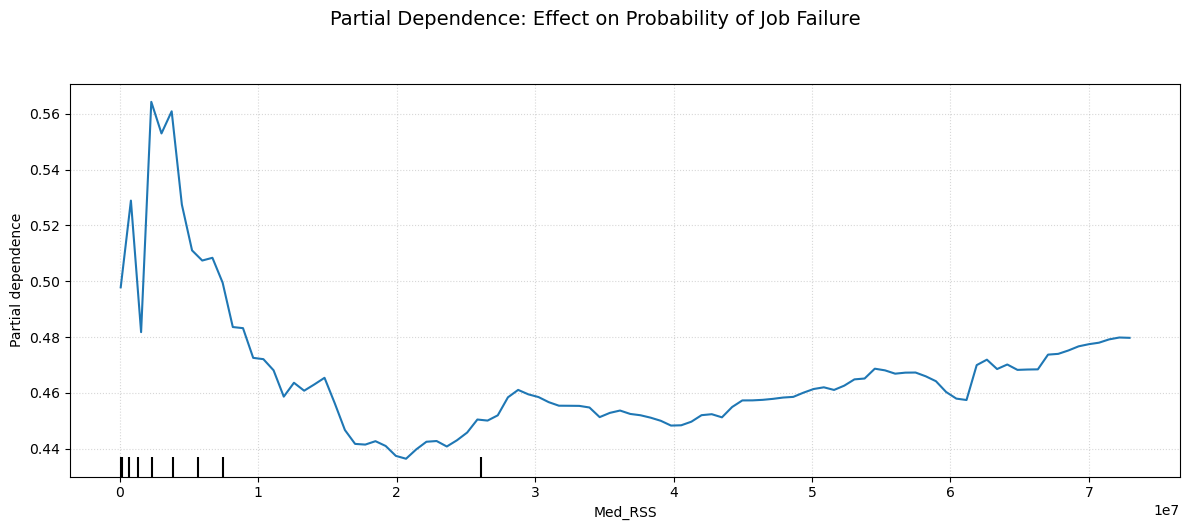

In [15]:
# Plot for Median RSS
features_to_plot = ['Med_RSS']
X_sample = X_test.sample(n=min(1000, len(X_val)), random_state=30)
fig, ax = plt.subplots(figsize=(12, 5))

display = PartialDependenceDisplay.from_estimator(
    estimator=Final_Model, 
    X=X_sample,
    features=features_to_plot,
    response_method='predict_proba',
    ax=ax,
    grid_resolution=100 
)

plt.suptitle("Partial Dependence: Effect on Probability of Job Failure", y=1.05, fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

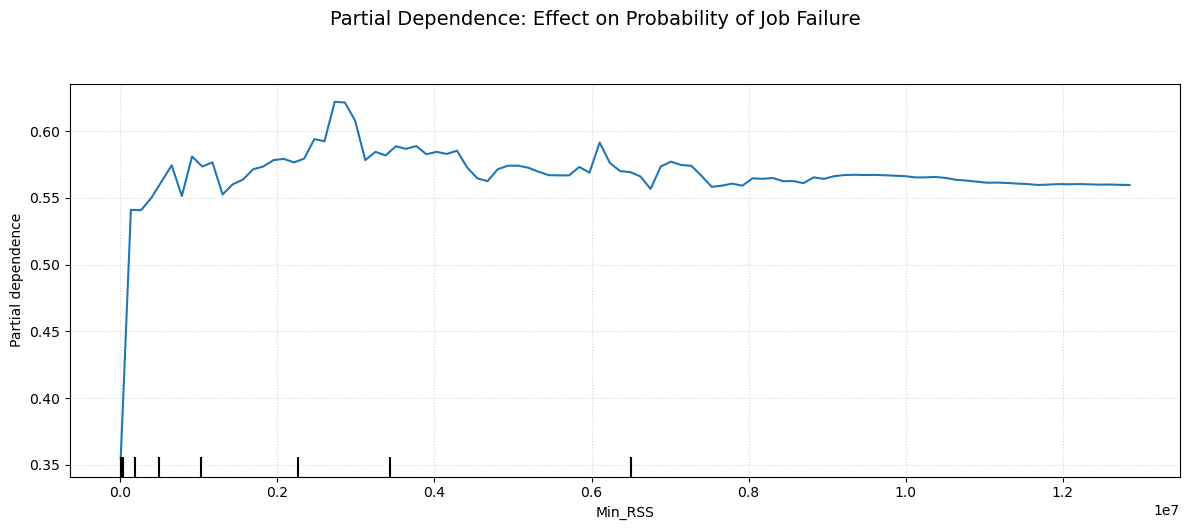

In [16]:
# Plot for Minimum RSS
features_to_plot = ['Min_RSS']
X_sample = X_test.sample(n=min(1000, len(X_val)), random_state=30)
fig, ax = plt.subplots(figsize=(12, 5))

display = PartialDependenceDisplay.from_estimator(
    estimator=Final_Model, 
    X=X_sample,
    features=features_to_plot,
    response_method='predict_proba', 
    ax=ax,
    grid_resolution=100 
)

plt.suptitle("Partial Dependence: Effect on Probability of Job Failure", y=1.05, fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

#
# Creating Waterfall plots via calculating SHAP Values
### This provides individual prediction interpretability

In [17]:
# Initialize the SHAP Explainer using Final Model
explainer = shap.TreeExplainer(Final_Model)

# Calculate SHAP values for test dataset
# This computes the impact scores for every row and every feature
shap_values = explainer(X_test)

# Extract the 1D array of values
failure_vals = shap_values.values[:, :, 0] 

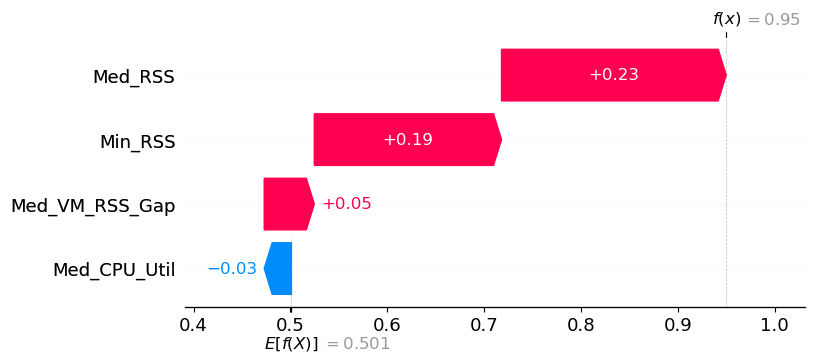

In [21]:
# Creating a waterfall plot for an example prediction

idx = 4
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0], 
    failure_vals[idx],         
    feature_names=X_test.columns.tolist(),
    max_display=20
)

In [ ]:
# Waterfall Plot Interpretation:

# The value of f(x) represents the model confidence that this job will end in a failure. So 95% confidence for this one.
# The value of Median RSS increased the probability of job failure by 23% compared to the historical baseline (50.1%)
# The value of Minimum RSS increased the probability of job failure by 19%
# The value of Median VMSize-RSS Gap increased the probability of job failure by 5%
# The value of Median CPU Utilization decreased the probability of job failure by 3%

#
# Final Model Precision and Recall Testing
### Prediction precision can be increased or decreased via changing the prediction threshold value

In [22]:
# Testing increasing precision for job failure predictions

y_probs = Final_Model.predict_proba(X_test)[:, 1]

# Updated threshold value
threshold = 0.17
y_pred_high_precision = (y_probs > threshold).astype(int)
precision = precision_score(y_test, y_pred_high_precision)
print(f"Threshold: {threshold}")

# Updated Classification Report
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_high_precision))

Threshold: 0.17

Full Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.76      0.85       748
        True       0.81      0.97      0.89       782

    accuracy                           0.87      1530
   macro avg       0.89      0.87      0.87      1530
weighted avg       0.89      0.87      0.87      1530



In [ ]:
# Can increase precision of Job Failure predictions to 97% by reducing recall to 76%.

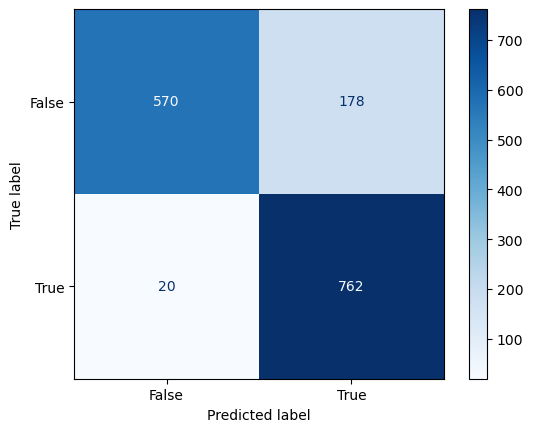

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_high_precision)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Final_Model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [24]:
# Testing increasing recall for job failure predictions

y_probs = Final_Model.predict_proba(X_test)[:, 1]

# Updated threshold value
threshold = 0.7
y_pred_high_recall = (y_probs > threshold).astype(int)
precision = precision_score(y_test, y_pred_high_recall)
print(f"Threshold: {threshold}")

# Updated Classification Report
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_high_recall))

Threshold: 0.7

Full Classification Report:
              precision    recall  f1-score   support

       False       0.85      0.97      0.90       748
        True       0.96      0.84      0.90       782

    accuracy                           0.90      1530
   macro avg       0.91      0.90      0.90      1530
weighted avg       0.91      0.90      0.90      1530



In [ ]:
# Can increase recall of Job Failure predictions to 97% by reducing precision to 85%.

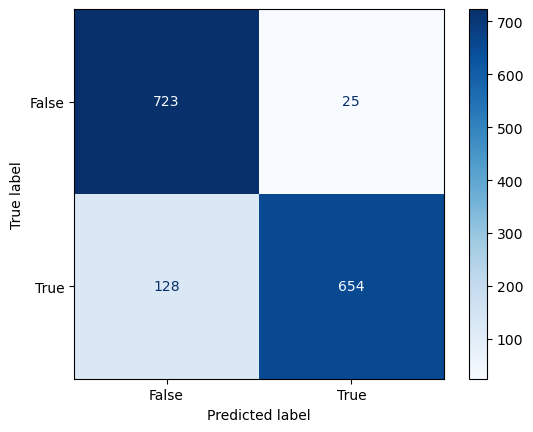

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_high_recall)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Final_Model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

#
# Business Impact
### Calculating a (very rough) estimate of how much compute time my model could save 

In [26]:
# Creating subset of all jobs that actually failed
failed_jobs = final_data[final_data['job_completed'] == False]
len(failed_jobs)

15298

In [39]:
avg_cpu_time = failed_jobs['duration_hours'].mean()
print(f"Average Duration of Jobs that Failed (Hours): {avg_cpu_time:.2f}")

Average Duration of Jobs that Failed (Hours): 23.29


In [32]:
total_cpu_time = failed_jobs['duration_hours'].sum()
print(f"Total Duration of Jobs that Failed (Hours): {total_cpu_time:.2f}")

Total Duration of Jobs that Failed (Hours): 356311.32


In [40]:
# Subtracting 2 hours for each failed job since my model needs that to make a prediction
# Multiplying by precision and recall of final model
print(f"Estimated compute hours saved (Job Failures Only): {(total_cpu_time-(2*(len(failed_jobs))))*0.92*0.93:.2f}")

Estimated compute hours saved (Job Failures Only): 278682.03


In [ ]:
# Assume an average job costs $0.05 in electricity to run for 1 hour (consuming 0.5 kWh electricity at a cost of $0.10/kWh)
# Conservative estimate of $18,500 in savings per year for ONLY jobs that failed
# Note that the MIT Supercloud dataset is only a 9-month snapshot

In [35]:
# Testing how my Final Model handles 5000 random jobs that were cancelled by the user
# None of these jobs were used to train the model

cancelled_jobs = pd.read_csv("Final_Run_Cancels.csv")
X_cancelled_jobs = cancelled_jobs[X_train.columns] 

# Get the final binary predictions (0 or 1)
predictions = Final_Model.predict(X_cancelled_jobs)
cancelled_jobs['Predicted_Class'] = predictions

# Get the raw probabilities [probability of 0, probability of 1]
probabilities = Final_Model.predict_proba(X_cancelled_jobs)
cancelled_jobs['Confidence_Class_1'] = probabilities[:, 1]

print(cancelled_jobs[['id_job', 'Predicted_Class', 'Confidence_Class_1']].head())

           id_job  Predicted_Class  Confidence_Class_1
0  46329754396938             True                0.99
1  10151349157034            False                0.40
2  58347945547439             True                0.98
3   5809216398803             True                0.90
4  21453407283690            False                0.00


In [36]:
# Calculating the percentage of Cancelled jobs predicted successes (True) or failures (False)
print(cancelled_jobs['Predicted_Class'].value_counts(normalize=True))

Predicted_Class
True     0.6322
False    0.3678
Name: proportion, dtype: float64


In [45]:
# Checking average job duration for cancelled jobs the model predicted would fail:

y_pred = Final_Model.predict(X_cancelled_jobs)
X_cancelled_with_preds = X_cancelled_jobs.copy()
X_cancelled_with_preds['Prediction'] = y_pred
X_cancelled_with_preds['id_job'] = cancelled_jobs.loc[X_cancelled_jobs.index, 'id_job']
X_cancelled_with_preds['duration_hours'] = cancelled_jobs.loc[X_cancelled_jobs.index, 'duration_hours']

# Filter for 'False' predictions and calculate the average of the target column
predicted_false_df = X_cancelled_with_preds[X_cancelled_with_preds['Prediction'] == 0]
average_value = predicted_false_df['duration_hours'].mean()

print(f"Average job duration for predicted False rows (in hours): {average_value:.2f}")

Average job duration for predicted False rows (in hours): 45.95


In [ ]:
# My model predicted that ~36% of Cancelled jobs would have been failures based on data from the first 2 hours
# There were 22,644 canceled jobs in total, 36% of that is 8150 jobs
# Cancelled jobs had a much higher average duration than jobs that failed

In [42]:
# Calculating compute time saved for cancelled jobs (assuming the random sample of 5000 was representative)
print(f"Estimated compute hours saved (Cancelled jobs only): {((average_value-2)*(8150))*0.92*0.93:.2f}")

Estimated compute hours saved (Cancelled jobs only): 306463.60


# Final (Very Rough) Estimates:
### Annual Compute Hours saved : 780,000
### Annual electricity saved: 390,000 kWh (equivalent of powering 35 homes for 1 year) 
### Annual cost savings : $39,000
### Annual Carbon Emission Reduction : 111 metric tons of CO2